# eoml walkthrough

End-to-end tour of the project: train the land cover classifier on EuroSAT, evaluate it, then retrieve an arbitrary Sentinel-2 scene from the Planetary Computer and run both analyses on it — land cover classification and NDVI.

```
EuroSAT (L1C chips) ──▶ train ──▶ checkpoint ─────────┐
                                                      ▼
STAC search ──▶ load_scene (L2A, 10 m grid) ──▶ classify_scene ──▶ class map
                        │
                        └──▶ ndvi ──▶ vegetation classes
```

Everything here is a thin call into `src/eoml/`; the CLI equivalents are noted along the way.

In [1]:
from pathlib import Path

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from eoml import indices, inference, models, train, viz
from eoml.data import eurosat, scenes

os.environ["TQDM_DISABLE"] = "1"

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)
CHECKPOINT = ARTIFACTS / "eurosat_resnet18.pth"

Using device: cuda


## 1. EuroSAT training data

EuroSAT is ~27k 64×64 px chips cut from Sentinel-2 L1C scenes, 13 spectral bands each, labeled with one of 10 land cover classes. torchgeo downloads it on first use (to `~/.cache/eoml/eurosat` by default; override with `get_datasets(root=...)`).

In [2]:
datasets = eurosat.get_datasets()
dataloaders = eurosat.get_dataloaders(datasets)
{split: len(ds) for split, ds in datasets.items()}

{'train': 16200, 'val': 5400, 'test': 5400}

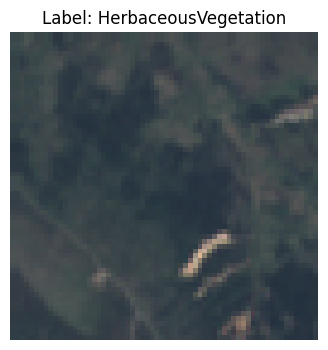

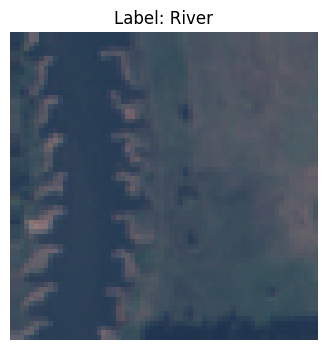

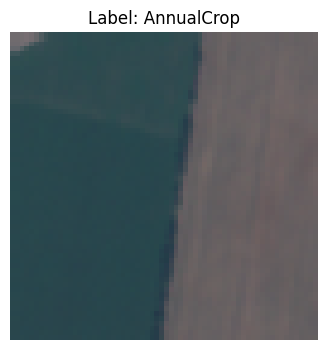

In [3]:
for i in torch.randint(len(datasets["train"]), (3,)):
    sample = datasets["train"][i]
    datasets["train"].plot(sample)

Two transforms, both from `eoml.data.eurosat`:

- **`get_preprocess()`** — `Normalize(0, 10000)`, scaling raw Sentinel-2 digital numbers to roughly [0, 1]. This exact transform is reused at inference time on downloaded scenes, so the model always sees identical inputs.
- **`get_augment()`** — random horizontal/vertical flips, training only.

In [4]:
preprocess = eurosat.get_preprocess().to(device)
augment = eurosat.get_augment().to(device)

## 2. Train the classifier

A ResNet-18 with self-supervised MoCo weights pretrained on Sentinel-2 imagery (via torchgeo), plus a fresh 10-class head. Three epochs of fine-tuning reaches ~96% test accuracy.

CLI equivalent: `eoml-train --epochs 3 --checkpoint artifacts/eurosat_resnet18.pth`

In [5]:
model = models.create_classifier()
train.fit(model, dataloaders, device, epochs=3, preprocess=preprocess, augment=augment);

Epoch 0: loss=486.02, val accuracy=79%
Epoch 1: loss=227.91, val accuracy=92%
Epoch 2: loss=91.68, val accuracy=95%


In [6]:
test_acc = train.evaluate(model, dataloaders["test"], device, preprocess)
print(f"Test accuracy: {test_acc:.1%}")

models.save_classifier(model, CHECKPOINT)
print(f"Saved checkpoint to {CHECKPOINT}")

Test accuracy: 94.3%
Saved checkpoint to ..\artifacts\eurosat_resnet18.pth


### Where does the model succeed, fail, and look?

The confusion matrix shows which classes get mixed up (typically the vegetation-adjacent ones: Permanent Crop vs Herbaceous Vegetation). Grad-CAM overlays show which pixels drove each prediction.

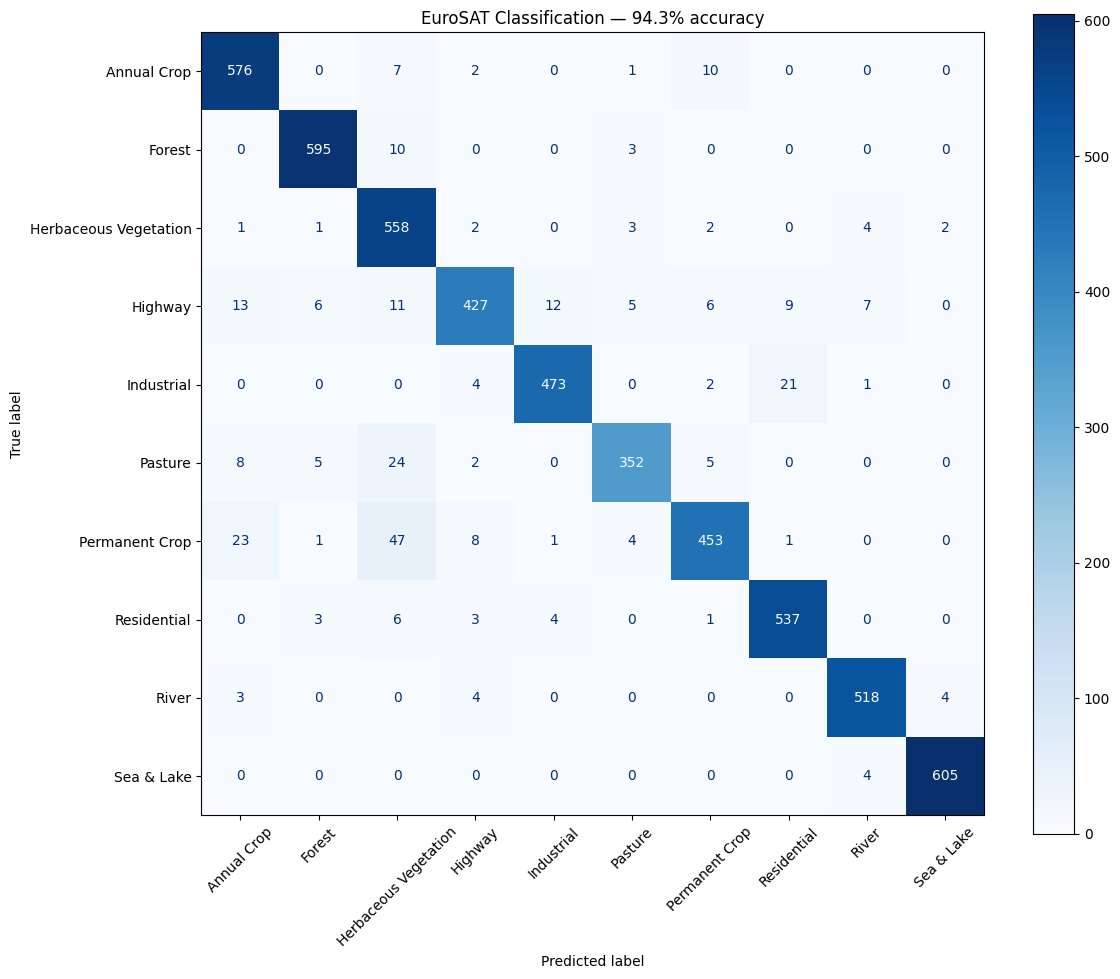

In [7]:
y_true, y_pred = train.predict(model, dataloaders["test"], device, preprocess)
viz.plot_confusion_matrix(y_true, y_pred);

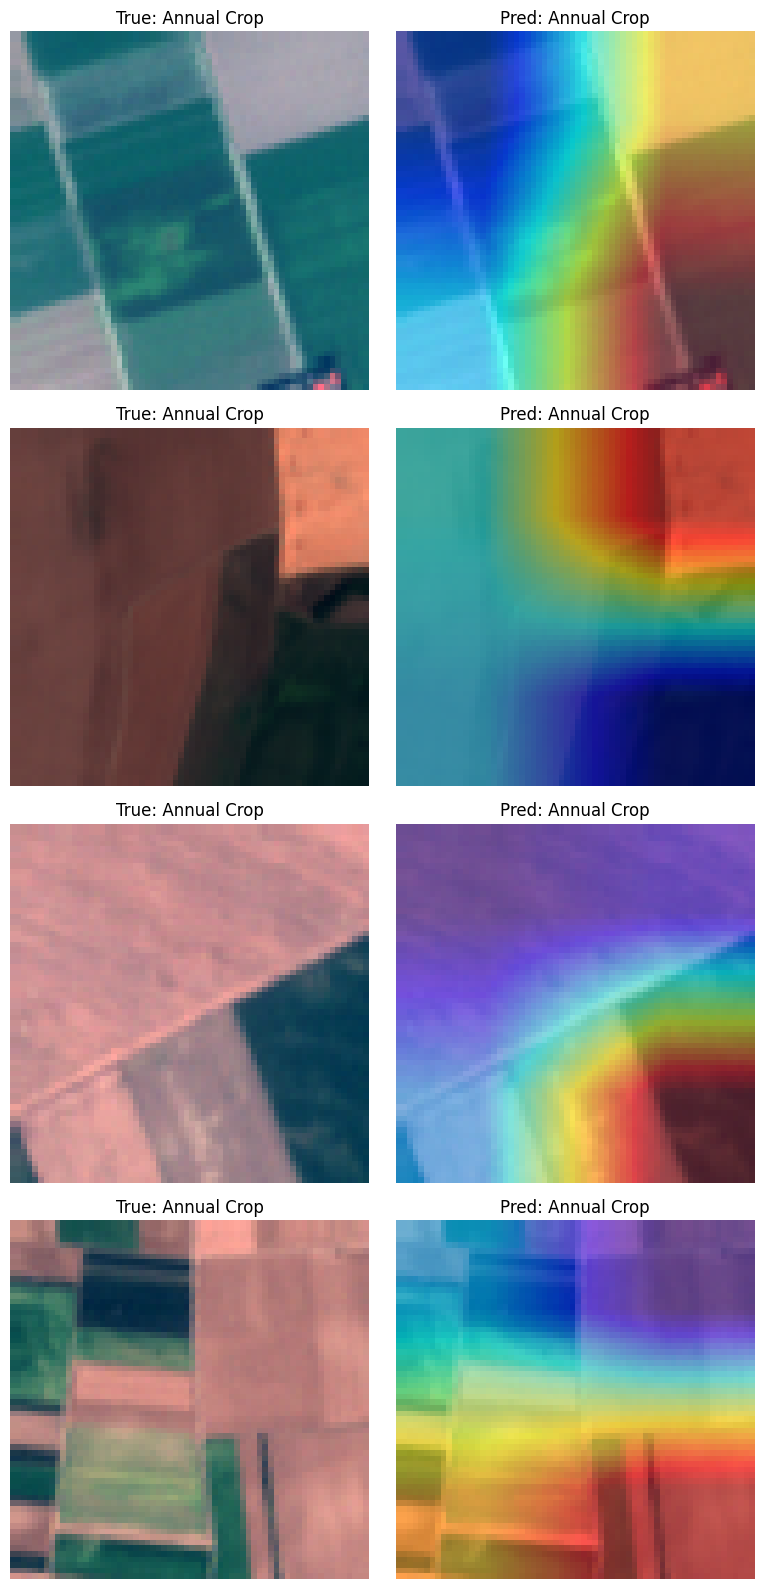

In [8]:
batch = next(iter(dataloaders["test"]))
viz.plot_gradcam_grid(model, batch["image"], batch["label"], device=device, n=4, preprocess=preprocess);

## 3. Retrieve an arbitrary Sentinel-2 scene

`eoml.data.scenes` searches the Planetary Computer STAC catalog for Sentinel-2 L2A scenes and loads any bbox as a single `(band, y, x)` DataArray: every band is clipped to the bbox and resampled onto the 10 m grid of B04, so the mixed 10/20/60 m bands stack cleanly.

Two subtleties handled here that a naive STAC query gets wrong:

- **Coverage**: STAC returns any granule *intersecting* the bbox — at swath edges that can be a nodata-padded sliver. `search_scenes` ranks results by bbox coverage first, cloud cover second.
- **Radiometric offset**: L2A scenes with processing baseline ≥ 04.00 (post-Jan 2022) carry a +1000 DN offset that EuroSAT-era data lacks. `load_band` subtracts it, so the classifier and NDVI see values on the scale they expect.

Here: an agricultural stretch of California's Central Valley — good variety for the classifier (crops, orchards, bare soil, the odd building).

In [9]:
bbox = [-120.5, 36.6, -120.35, 36.7]  # (west, south, east, north), ~13 x 11 km
items = scenes.search_scenes(bbox, "2024-06-01/2024-06-30", max_cloud_cover=20)
print(f"Found {len(items)} scenes")

item = items[0]  # best bbox coverage, then least cloudy
print(f"Using {item.id} (cloud cover {item.properties['eo:cloud_cover']:.1f}%, "
      f"covers {scenes.bbox_coverage(item, bbox):.0%} of bbox)")

Found 16 scenes
Using S2A_MSIL2A_20240629T183921_R070_T10SGF_20240630T032638 (cloud cover 0.0%, covers 100% of bbox)


In [10]:
scene = scenes.load_scene(item, bbox=bbox)
print(f"Scene: {scene.shape} (band, y, x), CRS: {scene.rio.crs}")

Scene: (12, 1146, 1372) (band, y, x), CRS: EPSG:32610


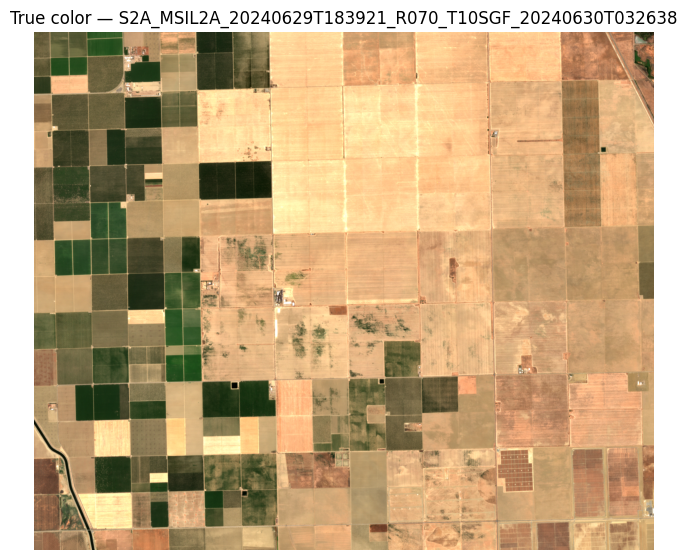

In [11]:
rgb = scene.sel(band=["B04", "B03", "B02"]).values.transpose(1, 2, 0)
rgb = np.clip(rgb / 3000, 0, 1)  # simple contrast stretch

plt.figure(figsize=(8, 7))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"True color — {item.id}");

## 4. Run the classifier on the scene

This is the bridge between the two halves of the project (`eoml.inference`). The EuroSAT model expects 13-band L1C chips; the downloaded scene is a 12-band L2A raster of arbitrary size. `classify_scene`:

1. reorders bands to the EuroSAT layout and **zero-fills B10** (cirrus — absent from L2A, near zero over clear land anyway),
2. applies the same `Normalize(0, 10000)` used in training,
3. tiles the scene into 64×64 chips and classifies each in batches,
4. reassembles predictions into a class map carrying the scene's CRS — each output pixel covers one 640 m chip.

We also pass `return_confidence=True` to keep each chip's max softmax probability, used in §6 and §7.

CLI equivalent: `eoml-classify --bbox -120.5 36.6 -120.35 36.7 --datetime 2024-06-01/2024-06-30`

Class map: (17, 21) chips


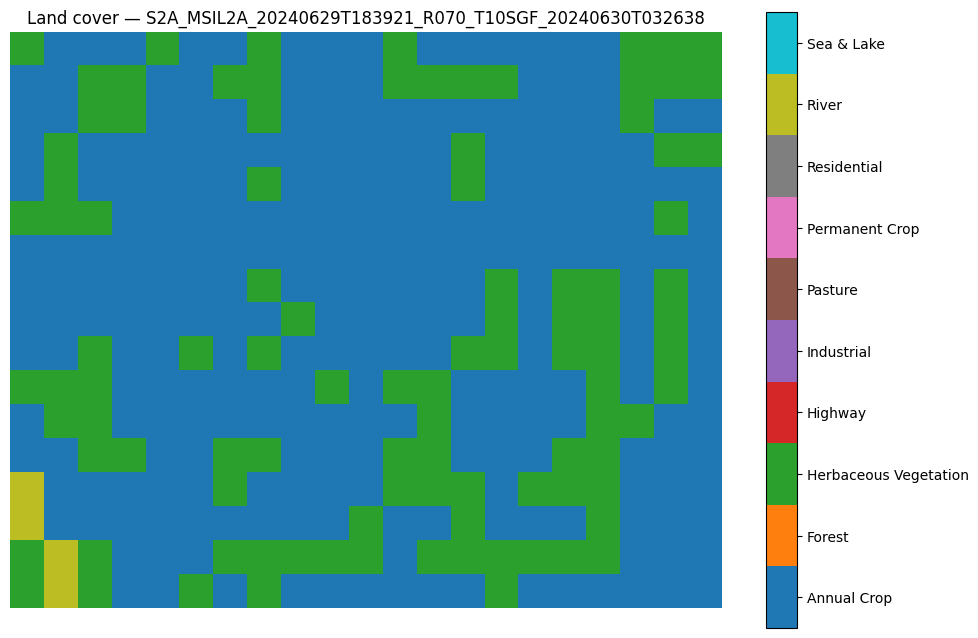

In [12]:
classifier = models.load_classifier(CHECKPOINT, device)
class_map, confidence = inference.classify_scene(
    classifier, scene, device, return_confidence=True
)
print(f"Class map: {class_map.shape} chips")

viz.plot_class_map(class_map, title=f"Land cover — {item.id}");

## 5. NDVI analysis of the same scene

NDVI = (NIR − Red) / (NIR + Red), i.e. bands B08 and B04 — which are already in the loaded scene, so this reuses the exact same data with no second download.

CLI equivalent: `eoml-ndvi --bbox -120.5 36.6 -120.35 36.7 --datetime 2024-06-01/2024-06-30`

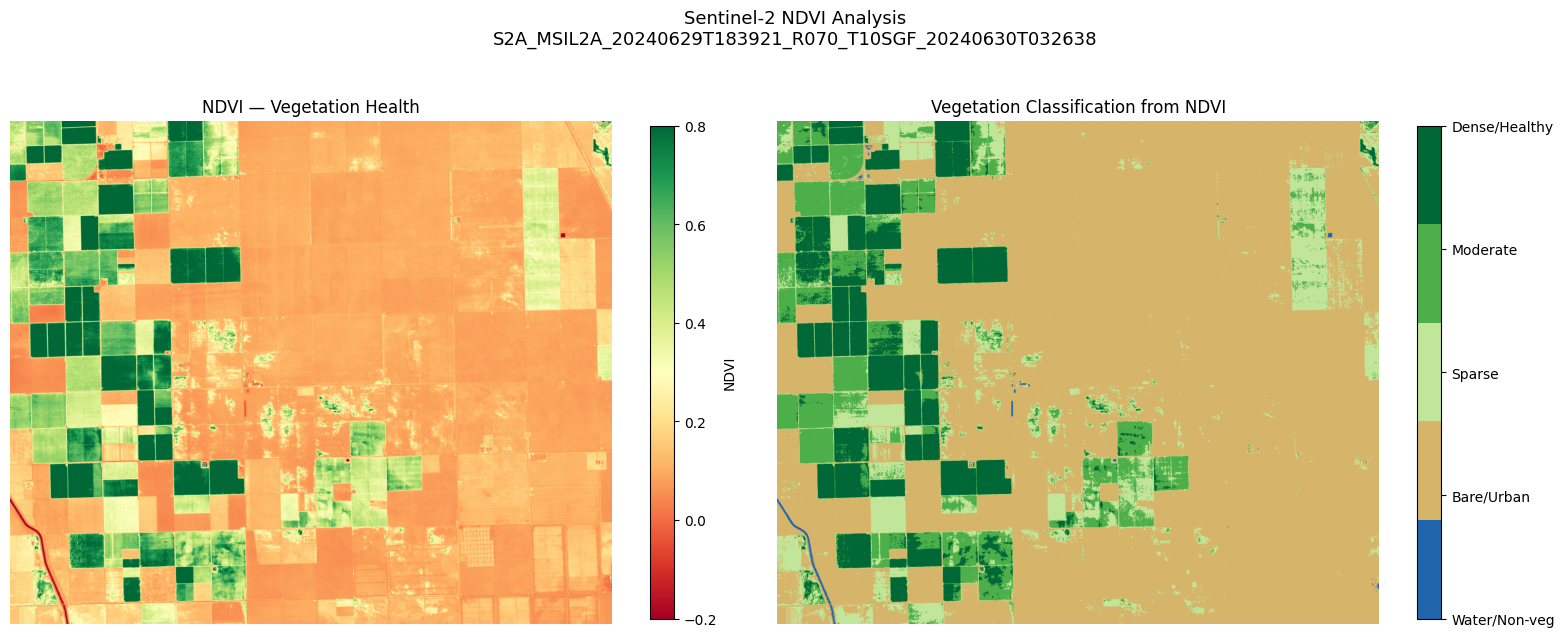

In [13]:
ndvi_da = indices.ndvi(scene)
veg_classes = indices.classify_ndvi(ndvi_da)

viz.plot_ndvi_analysis(ndvi_da, veg_classes, title=f"Sentinel-2 NDVI Analysis\n{item.id}");

## 6. Compare the two analyses, chip by chip

The learned classifier and the fixed NDVI formula are independent views, so where they agree and disagree is informative — but they have to be compared *on the same grid*. The tempting shortcut is to compare scene-wide fractions: the share of chips in vegetation-type classes against the share of pixels above an NDVI threshold. Those count different things over different supports (640 m chips vs 10 m pixels), so their rough closeness is a coincidence, not corroboration. Taken at face value it is also misleading here: nearly all chips land in vegetation-type classes, yet only about a third of pixels clear the NDVI vegetation threshold — read literally, a disagreement, not the agreement the numbers seem to suggest.

`inference.chip_stats` makes the comparison honest by putting NDVI on the classifier's grid: it aggregates the 10 m NDVI field into the same 640 m chips `classify_scene` used (verified to reproduce that tiling exactly), giving each chip a **mean NDVI** ("how green") and a **within-chip NDVI σ** ("how mixed"). Grouping those by predicted class, plus each class's mean confidence, lets us test two physically-motivated predictions:

1. **`AnnualCrop` should span a wide NDVI range, including low values.** EuroSAT's crop class spans many phenological stages, so the CNN might key on field *geometry* — rectangular parcels, furrow texture — where NDVI keys on *greenness*. A harvested or fallow field is spectrally bare (low NDVI) but still geometrically a crop field. If so, the two methods separate along the greenness axis.
2. **`HerbaceousVegetation` chips should carry elevated within-chip σ.** At 640 m a chip commonly straddles two to four Central Valley parcels at different stages. If Herbaceous Vegetation is where the model files spectrally mixed chips, its within-chip σ should stand out — a measurable version of the diffuse look those chips have in the RGB.

class                   chips  NDVI mean  within-chip σ  mean MSP
Annual Crop               253     +0.217          0.102     0.426
Herbaceous Vegetation     100     +0.279          0.089     0.375
River                       4     +0.148          0.175     0.443


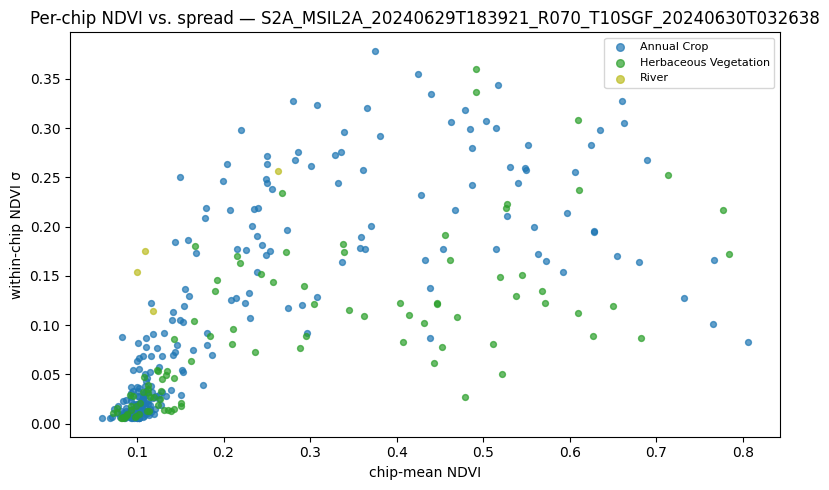

In [14]:
ndvi_mean, ndvi_std = inference.chip_stats(ndvi_da, class_map)

print(f"{'class':22s} {'chips':>6s} {'NDVI mean':>10s} {'within-chip σ':>14s} {'mean MSP':>9s}")
for idx in np.unique(class_map.values):
    m = class_map.values == idx
    print(f"{eurosat.CLASS_NAMES[idx]:22s} {int(m.sum()):6d} "
          f"{ndvi_mean.values[m].mean():+10.3f} {ndvi_std.values[m].mean():14.3f} "
          f"{confidence.values[m].mean():9.3f}")

viz.plot_ndvi_class_scatter(
    class_map, ndvi_mean, ndvi_std,
    title=f"Per-chip NDVI vs. spread — {item.id}",
);

Both predictions are overturned, and the *way* they fail is the result.

**Prediction 2, in the table:** Herbaceous Vegetation's within-chip σ (≈0.09) is if anything slightly *below* Annual Crop's (≈0.10), not elevated — it is not the model's dumping ground for spectrally mixed chips. The σ column's one real signal is River (≈0.18): water/land edges inside a 640 m chip, the single place internal spread discriminates.

**Prediction 1, in the scatter:** the class NDVI means overlap and the points show no clustering, so greenness does not separate the two classes. But greenness *is* doing real work — just orthogonally to the labels. The classifier calls nearly the whole scene Annual Crop, active and fallow fields alike, while NDVI cleanly resolves the active/fallow split (the green fields concentrated on the left). That is the honest form of the complementarity we were after: the classifier captures land-cover **type** (cropland) and is blind to vegetation **state**; NDVI captures state and is blind to type. The wide NDVI range lives *within* Annual Crop, not *between* the classes — which is exactly why it never showed up as class separation.

**So what is the Annual Crop vs Herbaceous Vegetation split?** On this scene it has no correlate in any variable available here — greenness, within-chip heterogeneity, or spatial position (Herbaceous Vegetation is sprinkled evenly through the cropland with no visible pattern). And it is *not* the two classes being confused: in the §2 confusion matrix both sit firmly on the diagonal, their errors going to Permanent Crop, Pasture, and Highway — none of which appear in this scene. The model is not mistaking one of these classes for the other in the way the matrix would predict.

The mean-MSP column is the tell. Every class here sits at ≈0.38–0.44, far below the near-1.0 confidence the model reaches on EuroSAT test (§7): it is not *confidently* drawing this distinction, it is hedging, Herbaceous Vegetation lowest of the three. That points away from a real non-spectral cue (which the model would apply confidently) and toward genuine out-of-distribution arbitrariness — the model near a decision boundary on tiles unlike EuroSAT's curated chips, its argmax tipping between two nearby classes without a ground basis. §7 makes that scene-wide picture explicit.

## 7. How confident is the model, and where isn't it?

`classify_scene` also returned each chip's **max softmax probability (MSP)** — the standard baseline for flagging out-of-distribution inputs. A 10-class softmax always sums to 1, so the model assigns *some* class to open water, cloud, or bare rock even though it has no label for them; MSP is how we catch that confident-but-unsupported behavior.

Two views. First, the MSP distribution on this scene against the EuroSAT test set — the benchmark the model was tuned on. Densities, not counts, since the test set has thousands of chips and the scene a few hundred; a leftward shift and a heavier low-confidence tail on the scene is the domain-shift signal. Second, the same threshold drawn back onto the map, hatching low-confidence chips so we can see *where* on the ground the model is unsure.

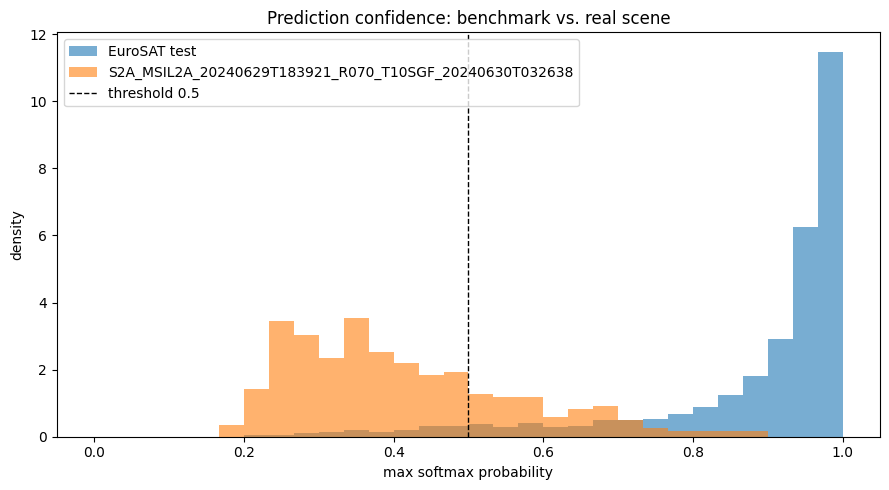

In [15]:
_, _, eurosat_conf = train.predict(
    model, dataloaders["test"], device, preprocess, return_confidence=True
)

viz.plot_confidence_histogram(
    eurosat_conf, confidence, threshold=0.5,
    reference_label="EuroSAT test", scene_label=item.id,
);

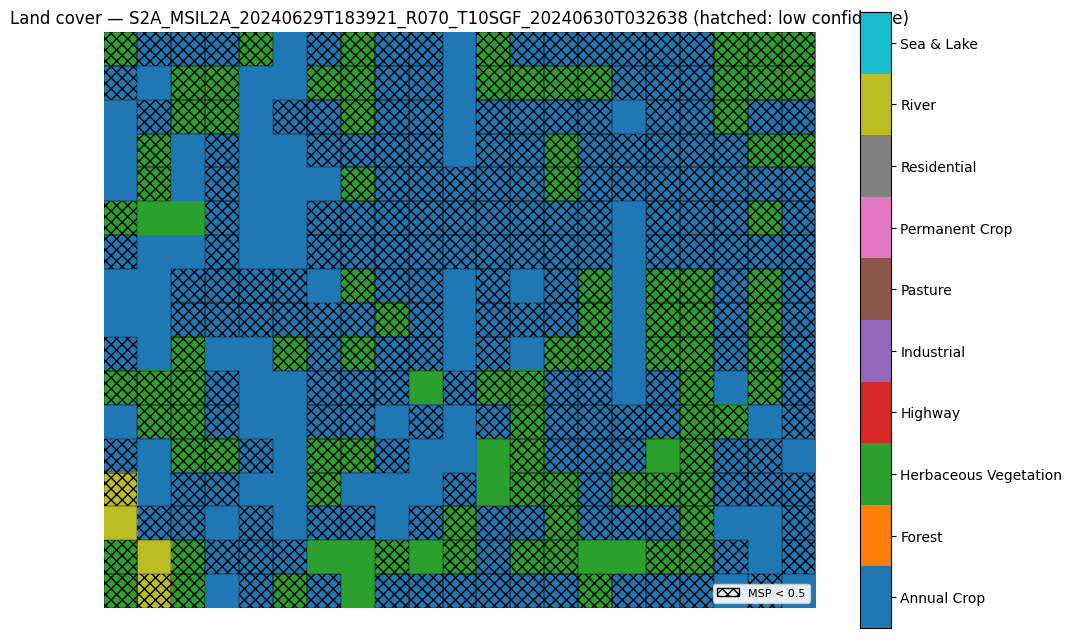

In [16]:
viz.plot_class_map(
    class_map, confidence=confidence, low_conf_threshold=0.5,
    title=f"Land cover — {item.id}",
);

The shift is stark: the scene's MSP peaks near 0.35 with a long right tail, while the EuroSAT test set piles up near 1.0. At the 0.5 threshold most of the scene is hatched — the benchmark model is broadly uncertain on real imagery.

The low confidence is not uniform, though. The higher-confidence chips tend to sit over the active green fields and thin out across the fallow ground — the same active/fallow split NDVI drew in §5 — so some of the vegetation *state* the classifier's label throws away (everything is Annual Crop) leaks back into its *confidence*. The cell below measures the effect; it is real but weak, a spatial tendency more than a clean relationship.

Pearson r(chip NDVI, chip MSP) = +0.21


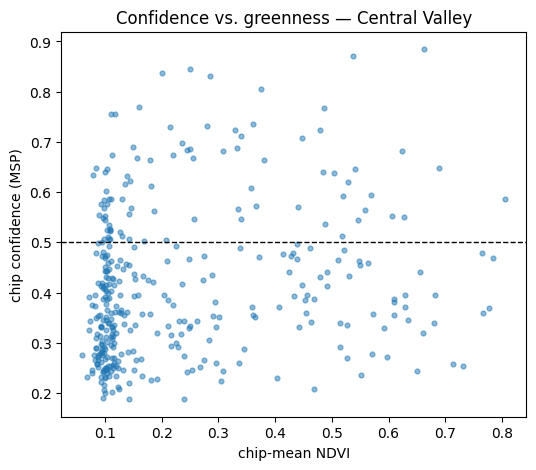

In [17]:
# Does confidence track greenness? Per-chip MSP vs. per-chip mean NDVI.
r = np.corrcoef(ndvi_mean.values.ravel(), confidence.values.ravel())[0, 1]
print(f"Pearson r(chip NDVI, chip MSP) = {r:+.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(ndvi_mean.values.ravel(), confidence.values.ravel(), s=12, alpha=0.5)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("chip-mean NDVI")
plt.ylabel("chip confidence (MSP)")
plt.title("Confidence vs. greenness — Central Valley");

## 8. A second scene: the Malibu coast

The natural way to stress the benchmark is to pick a scene that looks nothing like Europe. This bbox spans the Santa Monica Mountains meeting the Pacific near Malibu: open ocean, the urban ribbon along the Pacific Coast Highway, and Mediterranean chaparral — which I took to be a biome EuroSAT had never seen. The expectation going in was that this would be the *hard* case: alien land cover, low confidence, a heavier low-confidence tail than the Central Valley.

The workflow is exactly §3–§5, so we bundle it into one call.

In [18]:
def analyze_scene(bbox, datetime, max_cloud_cover=20):
    """Search, load, classify (with confidence), and NDVI a bbox — i.e. §3–§5."""
    item = scenes.search_scenes(bbox, datetime, max_cloud_cover=max_cloud_cover)[0]
    scene = scenes.load_scene(item, bbox=bbox)
    class_map, confidence = inference.classify_scene(
        classifier, scene, device, return_confidence=True
    )
    return dict(item=item, scene=scene, class_map=class_map,
                confidence=confidence, ndvi=indices.ndvi(scene))

# Santa Monica Mountains + Malibu coastline (west, south, east, north)
malibu = analyze_scene([-118.72, 33.98, -118.58, 34.08], "2024-06-01/2024-09-30",
                       max_cloud_cover=10)
print(f"Using {malibu['item'].id} "
      f"(cloud cover {malibu['item'].properties['eo:cloud_cover']:.1f}%)")

Using S2A_MSIL2A_20240825T182921_R027_T11SLT_20240826T015359 (cloud cover 0.0%)


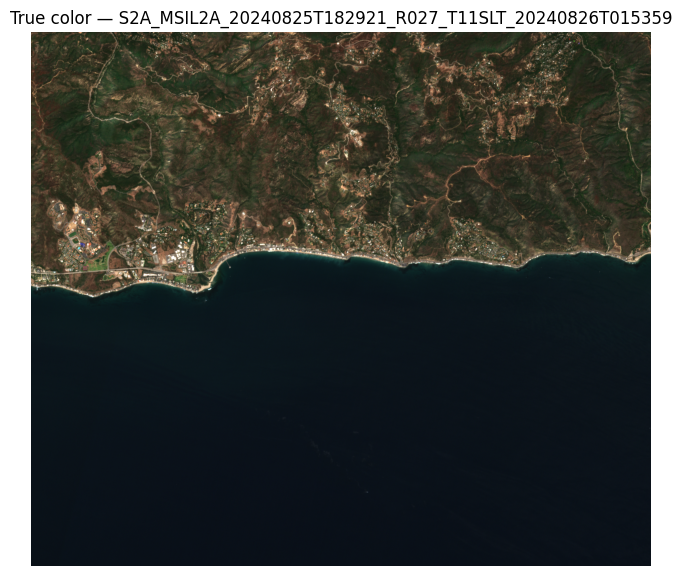

In [19]:
rgb = malibu["scene"].sel(band=["B04", "B03", "B02"]).values.transpose(1, 2, 0)
plt.figure(figsize=(8, 7))
plt.imshow(np.clip(rgb / 3000, 0, 1))
plt.axis("off")
plt.title(f"True color — {malibu['item'].id}");

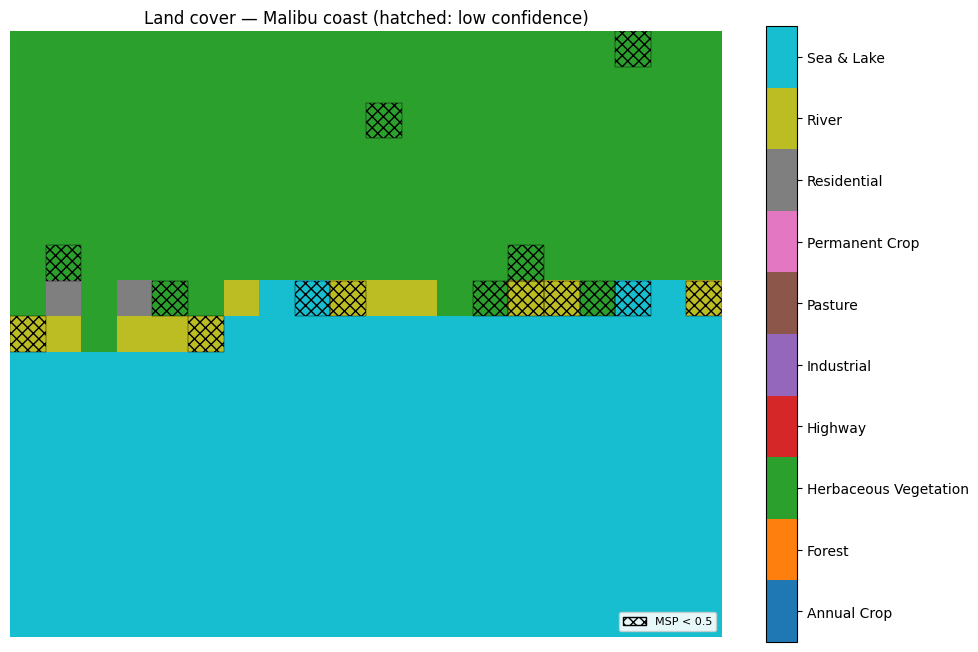

In [20]:
viz.plot_class_map(
    malibu["class_map"], confidence=malibu["confidence"], low_conf_threshold=0.5,
    title=f"Land cover — Malibu coast",
);

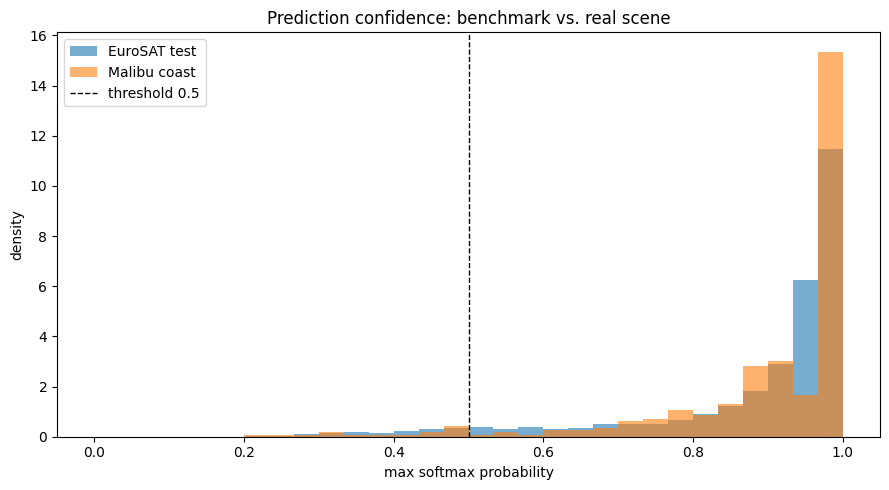

In [21]:
viz.plot_confidence_histogram(
    eurosat_conf, malibu["confidence"], threshold=0.5,
    reference_label="EuroSAT test", scene_label="Malibu coast",
);

That expectation was backwards, and the assumption behind it was wrong too: Malibu is the *easier* scene for this model.

The water goes confidently and correctly to Sea & Lake — EuroSAT has that class, so open ocean is not out-of-distribution. The chaparral goes to Herbaceous Vegetation with high confidence, and that is very likely *correct*, not a lucky guess: EuroSAT is a European dataset, southern Europe is Mediterranean, and California shares that Mediterranean biome, so the chaparral plausibly resembles training scenes rather than confusing the model. The coastal strip picks up Residential and some River. Confidence is high across most of the scene and drops only where it should — the immediate coastline, where 640 m chips genuinely mix water, beach, and built-up land and no single EuroSAT class fits. The scene's MSP histogram tracks the EuroSAT test set's shape, where the Central Valley's sat far to the left.

Why is the *exotic-looking* scene more in-distribution than the familiar farmland? The intuition that chose these scenes — "California farmland resembles European farmland, so it should be the easy case" — reasoned about the wrong kind of similarity, land use. What actually governs transfer is whether individual 640 m chips resemble EuroSAT's curated, single-cover tiles, and Malibu is closer on at least two counts. *Structurally*, it resolves into large near-homogeneous blocks — kilometres of uniform ocean, continuous chaparral, a solid urban strip — each of which looks like one clean EuroSAT patch, where the Central Valley resolves into a fine mosaic of small parcels and bare fallow ground. *Spectrally*, its Mediterranean vegetation may simply be in-distribution, as the confident chaparral call suggests. Two scenes can't separate the structural contribution from the spectral one — they are confounded here — but either way, land-use familiarity was the wrong axis: the exotic-looking coast sat closer to the benchmark than the mundane farmland.

A note on confidence across both scenes. It behaved sensibly as an out-of-distribution flag — low where inputs are genuinely mixed or unfamiliar (the fallow mosaic, the coastline, the ground-arbitrary Central Valley vegetation split), high where the coarse call is both solid and in-distribution (ocean, chaparral, active crops). The standard caveat still holds in principle — MSP measures typicality, not correctness, so a model can be confidently wrong and MSP will not catch it — but these two scenes did not actually produce such a case; the confident calls we could check were all reasonable. Confidence proved more trustworthy here than the framing going in expected.

---

That's the whole pipeline, on two scenes that stress the model in opposite directions — and not the directions you might guess. To point it somewhere else, change `bbox` and `datetime` — or use `analyze_scene(...)` from §8 — or skip the notebook entirely:

```sh
eoml-train --epochs 3
eoml-classify --bbox WEST SOUTH EAST NORTH --datetime 2024-06-01/2024-06-30 --confidence
eoml-ndvi     --bbox WEST SOUTH EAST NORTH --datetime 2024-06-01/2024-06-30
```

The `--confidence` flag hatches low-confidence chips on the saved class map and writes a confidence heatmap alongside it — the CLI version of §7.